In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import lumicks.pylake as lk
#from mpl_point_clicker import clicker
import csv
import matplotlib.patches as mpatches
#%matplotlib widget
from scipy.signal import find_peaks


# Variables  ######################################################################################################
# directory = r'D:\2022-8-24 1uM cGAScat automated 3rd' ## cat domain
directory = r"E:\C-trap\data\mcGAS\121725"  ##insert appropriate path 
###################################################################################################################

# Files in directory 
files = []
numis = 0
for filename in os.listdir(directory):
    if filename.endswith(".h5") and 'Kymograph' in filename or 'reference' in filename:
        print(numis, os.path.join(filename))
        files.append(os.path.join(directory, filename))
        numis+=1
    else:
        continue
print('There are ',numis,' Kymograph file(s) in the directory.')       
os.chdir(directory +'/')

0 20251217-142417 Marker DNA 1 reference curve.h5
1 20251217-144340 Marker DNA 2 reference curve.h5
2 20251217-150234 Marker DNA 3 reference curve.h5
3 20251217-151519 Kymograph 10 Pull 1 DNA 3.h5
4 20251217-151636 Kymograph 11 Pull 2 DNA 3.h5
5 20251217-151753 Kymograph 12 Pull 3 DNA 3.h5
6 20251217-152220 Marker DNA 4 reference curve.h5
7 20251217-152329 Kymograph 13 PM DNA 4.h5
8 20251217-153504 Kymograph 14 Pull 1 DNA 4.h5
9 20251217-153621 Kymograph 15 Pull 2 DNA 4.h5
10 20251217-153738 Kymograph 16 Pull 3 DNA 4.h5
11 20251217-154803 Marker DNA 5 reference curve.h5
12 20251217-154912 Kymograph 17 PM DNA 5.h5
13 20251217-160056 Kymograph 18 Pull 1 DNA 5.h5
14 20251217-160213 Kymograph 19 Pull 2 DNA 5.h5
15 20251217-160329 Kymograph 20 Pull 3 DNA 5.h5
16 20251217-160703 Marker DNA 6 reference curve.h5
17 20251217-160812 Kymograph 21 PM DNA 6.h5
18 20251217-161950 Kymograph 22 Pull 1 DNA 6.h5
19 20251217-162107 Kymograph 23 Pull 2 DNA 6.h5
20 20251217-162224 Kymograph 24 Pull 3 DNA 6

# Select sample and reference curves

In [2]:
sample_curve_files = []
numis = 0
for filename in os.listdir(directory):
    if filename.endswith(".h5") and "DNA 2" in filename and "Pull 1" in filename:
        print(numis, os.path.join(filename))
        sample_curve_files.append(os.path.join(directory, filename))
        numis+=1
    else:
        continue
print('There are ',numis,' file(s) in the sample selection.') 

ref_curve_files = []
numis = 0
for filename in os.listdir(directory):
     if filename.endswith(".h5") and 'Marker DNA 2 reference' in filename:
        print(numis, os.path.join(filename))
        ref_curve_files.append(os.path.join(directory, filename))
        numis+=1
     else:
         continue
print('There are ',numis,' file(s) in the reference selection.') 

0 20251217-145619 Kymograph 6 Pull 1 DNA 2.h5
There are  1  file(s) in the sample selection.
0 20251217-144340 Marker DNA 2 reference curve.h5
There are  1  file(s) in the reference selection.


# Plot raw data F vs time for sample and reference curves

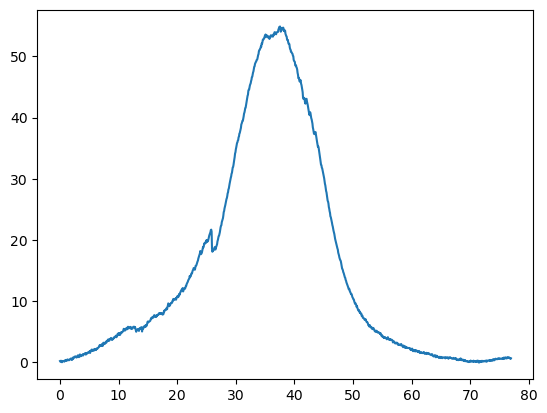

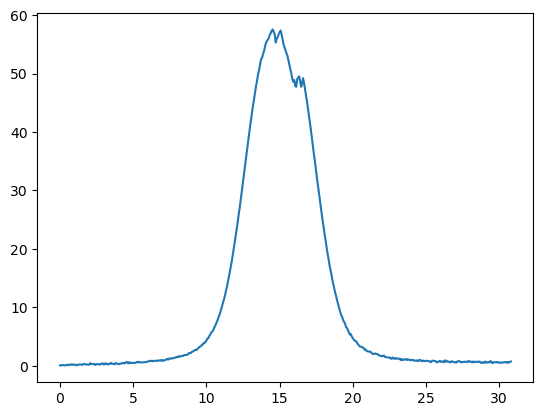

In [3]:
plt.figure(1)
for file in sample_curve_files: 
    file_is = lk.File(file)
    force2x_lf = file_is["Force LF"]["Force 2x"]
    force2y_lf = file_is["Force LF"]["Force 2y"]
    force_lf = np.sqrt((force2x_lf.data**2 + force2y_lf.data**2))
    distance_lf = file_is.distance1.data
    time_lf = force2x_lf.seconds

    plt.plot(time_lf, force_lf)
    
plt.figure(2)
for file in ref_curve_files: 
    file_is = lk.File(file)
    force2x_lf = file_is["Force LF"]["Force 2x"]
    force2y_lf = file_is["Force LF"]["Force 2y"]
    force_lf = np.sqrt((force2x_lf.data**2 + force2y_lf.data**2))
    distance_lf = file_is.distance1.data
    time_lf = force2x_lf.seconds
    
    plt.plot(time_lf, force_lf)

# Plot baseline adjusted F vs time for sample and reference curve

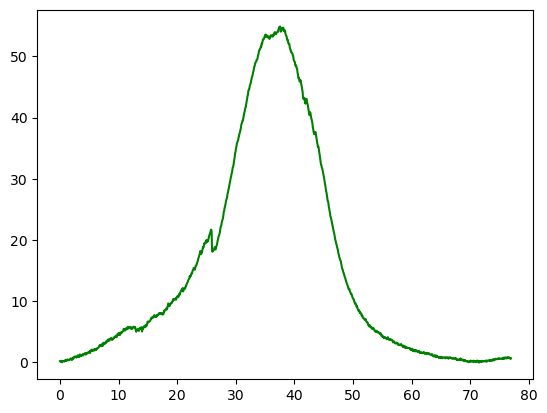

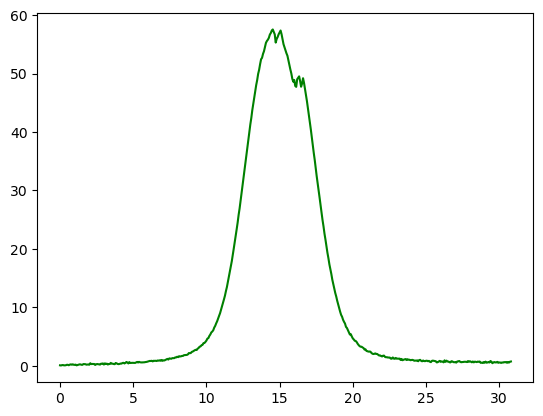

In [4]:
plt.figure(1)
for files in sample_curve_files:
    file = lk.File(files)
    force2x_lf = file["Force LF"]["Force 2x"]
    force2y_lf = file["Force LF"]["Force 2y"]
    time_lf = force2x_lf.seconds
    distance_lf = file.distance1.data
    force_lf = np.sqrt((force2x_lf.data**2 + force2y_lf.data**2))
    plt.plot(time_lf, force_lf, color='green')
    
plt.figure(2)
for files in ref_curve_files:
    file = lk.File(files)
    force2x_lf = file["Force LF"]["Force 2x"]
    force2y_lf = file["Force LF"]["Force 2y"]
    time_lf = force2x_lf.seconds
    distance_lf = file.distance1.data#[time_lf>38]
    force_lf = np.sqrt((force2x_lf.data**2 + force2y_lf.data**2))#[time_lf>38]
    plt.plot(time_lf, force_lf, color='green')

# Sample FD Pull and retraction color coded

The number of replicates = 1


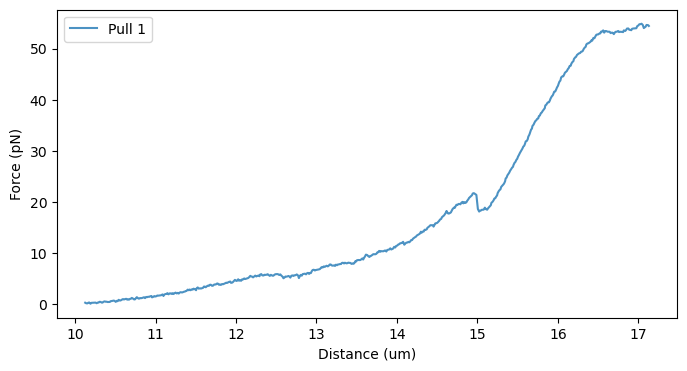

In [5]:
plt.close()
n_value_curves = 0 

figure, ax = plt.subplots(figsize=(8,4))
for files in sample_curve_files:
    file = lk.File(files)
    force2x_lf = file["Force LF"]["Force 2x"]
    force2y_lf = file["Force LF"]["Force 2y"]
    time_lf = force2x_lf.seconds
    distance_lf = file.distance1.data[time_lf<38]
    force_lf = np.sqrt((force2x_lf.data**2 + force2y_lf.data**2))[time_lf<38]
    ##if np.average(force_lf[time_lf<5]) > 5:   #####Remove data points where Dist < 10um #######
        #force_lf = force_lf[distance_lf>10]
        #time_lf = time_lf[distance_lf>10]
        #distance_lf = distance_lf[distance_lf>10]
    #force_lf = force_lf-np.average(force_lf[time_lf>30]) ########Subtract out the baseline#########
    plt.plot(distance_lf, force_lf, alpha=0.8)
    plt.ylabel("Force (pN)")
    plt.xlabel("Distance (um)")
    ax.legend(['Pull 1', 'Pull 2', 'Pull 3'])
    n_value_curves +=1
    
   # plt.savefig('DNA 1 sample_pull_curves 110724.pdf')
   # plt.savefig('DNA 1 sample_pull_curves 110724.png')

print('The number of replicates = '+str(n_value_curves))

The number of replicates = 1


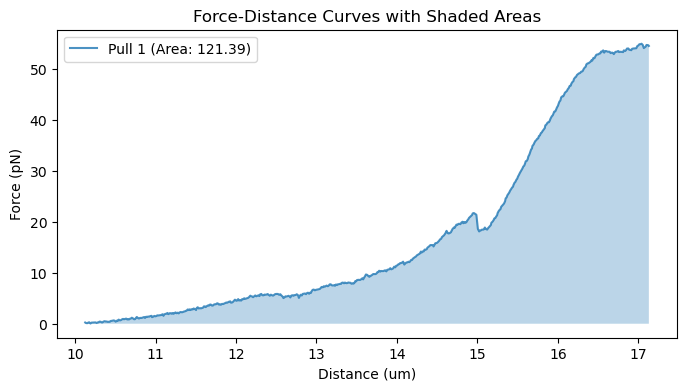

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps

plt.close()
n_value_curves = 0
areas = []  # List to store area under each curve

figure, ax = plt.subplots(figsize=(8, 4))
for files in sample_curve_files:
    file = lk.File(files)
    force2x_lf = file["Force LF"]["Force 2x"]
    force2y_lf = file["Force LF"]["Force 2y"]
    time_lf = force2x_lf.seconds
    distance_lf = file.distance1.data[time_lf < 38]
    force_lf = np.sqrt((force2x_lf.data**2 + force2y_lf.data**2))[time_lf < 38]
    
    # Calculate the area under the curve
    area = np.trapz(force_lf, distance_lf)
    areas.append(area)
    
    # Plot the curve
    plt.plot(distance_lf, force_lf, alpha=0.8, label=f'Pull {n_value_curves+1} (Area: {area:.2f})')
    
    # Shade the area under the curve
    plt.fill_between(distance_lf, force_lf, alpha=0.3)
    
    plt.ylabel("Force (pN)")
    plt.xlabel("Distance (um)")
    n_value_curves += 1

# Add legend and title
plt.legend()
plt.title("Force-Distance Curves with Shaded Areas")

# Print total number of curves
print(f'The number of replicates = {n_value_curves}')

# Optionally, save the plot if needed
plt.savefig('DNA 2_sample_pull_curve_with_shaded_areas.pdf')
plt.savefig('DNA 2_sample_pull_curve_with_shaded_areas.png')


The number of replicates = 1


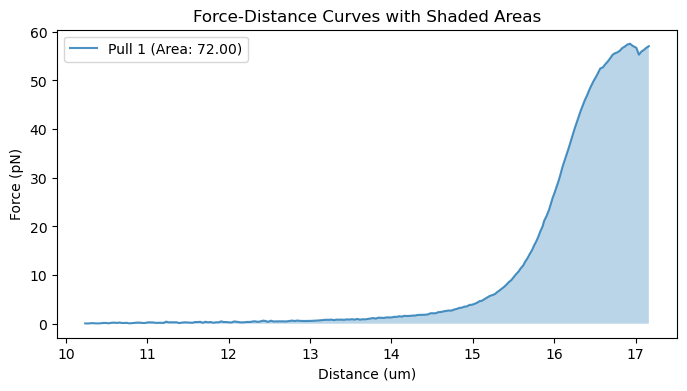

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps

plt.close()
n_value_curves = 0
areas = []  # List to store area under each curve

figure, ax = plt.subplots(figsize=(8, 4))
for files in ref_curve_files:
    file = lk.File(files)
    force2x_lf = file["Force LF"]["Force 2x"]
    force2y_lf = file["Force LF"]["Force 2y"]
    time_lf = force2x_lf.seconds
    distance_lf = file.distance1.data[time_lf < 15]
    force_lf = np.sqrt((force2x_lf.data**2 + force2y_lf.data**2))[time_lf < 15]
    
    # Calculate the area under the curve
    area = np.trapz(force_lf, distance_lf)
    areas.append(area)
    
    # Plot the curve
    plt.plot(distance_lf, force_lf, alpha=0.8, label=f'Pull {n_value_curves+1} (Area: {area:.2f})')
    
    # Shade the area under the curve
    plt.fill_between(distance_lf, force_lf, alpha=0.3)
    
    plt.ylabel("Force (pN)")
    plt.xlabel("Distance (um)")
    n_value_curves += 1

# Add legend and title
plt.legend()
plt.title("Force-Distance Curves with Shaded Areas")

# Print total number of curves
print(f'The number of replicates = {n_value_curves}')

# Optionally, save the plot if needed
plt.savefig('DNA 2_ref_pull_curve_with_shaded_areas.pdf')
plt.savefig('DNA 2_ref_pull_curve_with_shaded_areas.png')
